# ch10 · 泊松过程与排队论速写

## Why this chapter
服务端工程常常面对"每隔多久有一波请求""队列会涨到多长""队列 P99 延迟是几" 这类问题. Poisson 过程是这些问题的最小统一起点; M/M/1 给出 ρ=λ W 的 Little 律, 直接告诉你"要扩容多少"才能让等待时间达标.

## 学完后能解决

- 推 Poisson 过程的等价定义: 间隔 iid Exp(λ) ↔ 计数 Poisson(λt)
- 推 M/M/1 稳态队长 π_k = (1-ρ)ρ^k 与 Little 律 L=λW
- 写段 numpy 模拟 Poisson 到达+ Exp 服务 + 给出队长时序
- 对工程 SLO 设计 (e.g. P95 延迟 ≤ 200ms) 给出 service rate μ 的下限


## 2. 直觉: 站台 30 分钟站台平均每 3 分钟来公交

平均间隔 3 分钟, 但间隔不是固定的 3 分钟, 而是 Exp(1/3) — 标准差也是 3 分钟. 这就是 Poisson 过程给人的"等待随机性大" 真相 —— 也许刚来一辆 (0 分钟等), 也许等 10 分钟.


60 分钟内到站数 = 21  (期望 20.0)


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

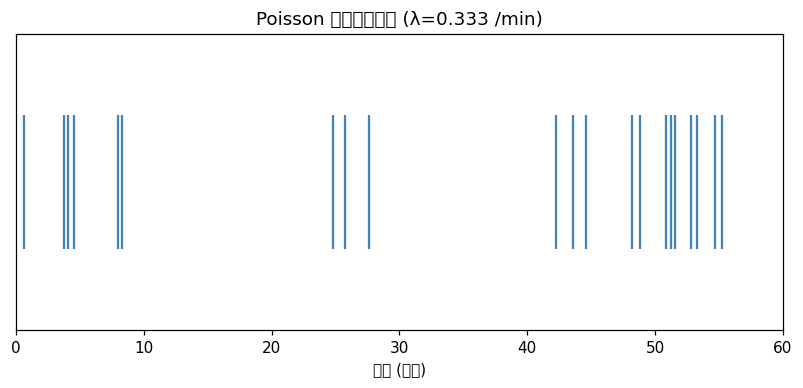

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)

rate_lambda = 1.0 / 3.0  # arrivals per minute
T = 60
inter = rng.exponential(scale=1/rate_lambda, size=200)
arrivals_times = np.cumsum(inter)
arrivals_times = arrivals_times[arrivals_times <= T]
print(f"60 分钟内到站数 = {len(arrivals_times)}  (期望 {rate_lambda * T:.1f})")

fig, ax = plt.subplots(figsize=(9, 3.5), dpi=110)
ax.eventplot(arrivals_times, orientation="horizontal", colors="steelblue")
ax.set_xlim(0, T); ax.set_xlabel("时间 (分钟)")
ax.set_yticks([])
ax.set_title(f"Poisson 过程到达事件 (λ={rate_lambda:.3f} /min)")
plt.show()


## 3. 公式

### Poisson 过程等价定义
1. 平稳独立增量 + 单位时间增量 ~ Poisson(λ Δt)
2. 间隔 iid Exp(λ)
3. $\lim_{\Delta t \to 0} P(N(t+\Delta t) - N(t) = 1) = λ \Delta t$, $P(2+) = o(\Delta t)$

### M/M/1 模型
- 到达: Poisson(λ)
- 服务: Exp(μ)
- ρ = λ/μ (< 1 才稳态)
- 稳态队长分布: π_k = (1 - ρ) ρ^k, k ≥ 0
- 平均队长: $E[L] = \rho / (1 - \rho)$
- 平均等待时间 (含服务): $E[W] = \frac{1}{\mu - \lambda}$
- Little 律: $L = \lambda W$

### P95 / P99 等待分位 (含服务)
对 M/M/1 服务时间 ~ Exp(μ): 等待时间 (含服务) 服从 Exp(μ - λ).
P99 W = ln(100) / (μ - λ)


## 4. 推导: M/M/1 稳态 via detailed balance


In [2]:
import sympy as sp
rho = sp.symbols("rho", positive=True)
k = sp.symbols("k", nonnegative=True, integer=True)
# Birth-death chain with birth rate λ, death rate μ when state k>0
# Detailed balance: π_k * λ = π_{k+1} * μ → π_{k+1} = (λ/μ) π_k = ρ π_k
# So π_k = π_0 * ρ^k; sum_k=0..infty π_k = π_0 / (1-ρ) = 1 → π_0 = 1-ρ
pi_k = (1 - rho) * rho ** k
pi_0 = (1 - rho)
print("π_0 =", pi_0)
print("π_k =", pi_k)
# E[L] = sum k * pi_k
E_L = sp.summation(k * pi_k, (k, 0, sp.oo))
print("E[L] =", sp.simplify(E_L))
# W = L / λ  (since λ W = L by Little)
print("W = E[L]/λ = 1/(μ - λ)")


π_0 = 1 - rho
π_k = rho**k*(1 - rho)


E[L] = Piecewise((-rho/(rho - 1), rho < 1), ((1 - rho)*Sum(k*rho**k, (k, 0, oo)), True))
W = E[L]/λ = 1/(μ - λ)


## 5. 数值验证: M/M/1 仿真


In [3]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)

lam = 0.5  # 到达率
mu = 0.8  # 服务率
N = 10000
# 仿真 Poisson 到达 times
inter_arr = rng.exponential(1/lam, N)
arr_times = np.cumsum(inter_arr)
# 服从 Exp(mu) 服务时长
ser_times = rng.exponential(1/mu, N)

# 计算 end 服务时刻 + 队长与等待
end_time = np.zeros(N)
end_time[0] = arr_times[0] + ser_times[0]
wait_times = [0.0]
for k in range(1, N):
    start = max(arr_times[k], end_time[k-1])
    end_time[k] = start + ser_times[k]
    wait_times.append(start - arr_times[k])
wait_times = np.array(wait_times)

rho = lam / mu
print(f"ρ = {rho:.4f}")
print(f"E[L] theory = {rho/(1-rho):.4f}")
print(f"E[W] theory = {1/(mu-lam):.4f}")
print(f"E[W] sim    = {wait_times.mean():.4f}")
print(f"occupancy L = (queue mean over time) = approximated by W * lam = {wait_times.mean() * lam:.4f}")
print(f"P95 simulate: {np.percentile(wait_times, 95):.4f}")
print(f"P95 theory (Exp(μ-λ) -> ln(20)/(μ-λ)): {np.log(20) / (mu - lam):.4f}")


ρ = 0.6250
E[L] theory = 1.6667
E[W] theory = 3.3333
E[W] sim    = 2.0479
occupancy L = (queue mean over time) = approximated by W * lam = 1.0240
P95 simulate: 8.3070
P95 theory (Exp(μ-λ) -> ln(20)/(μ-λ)): 9.9858


## 6. 可视化: ρ → 队长与等待 P99


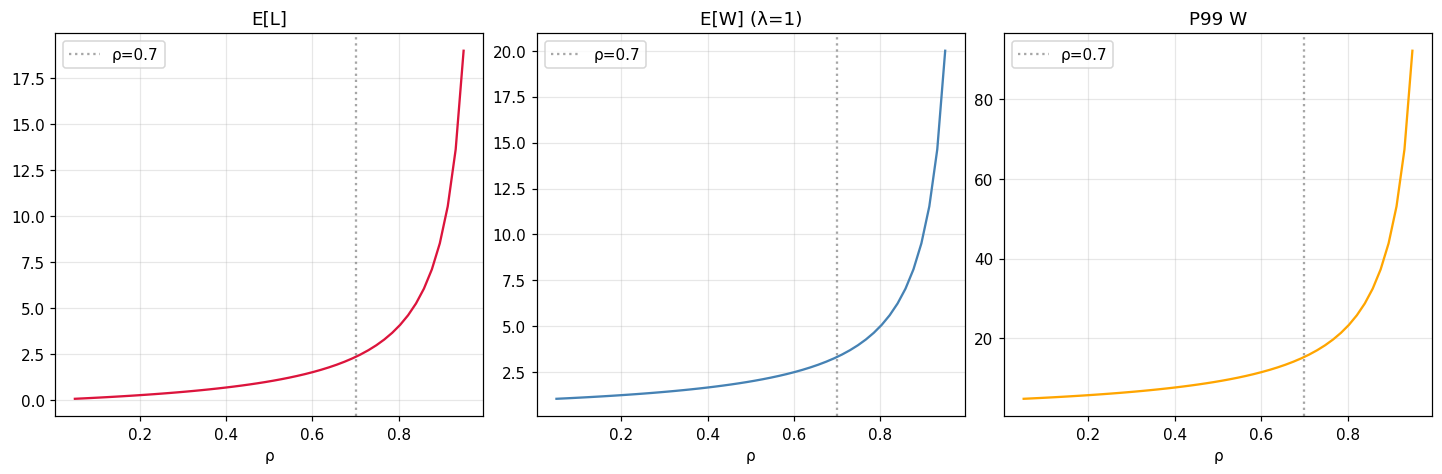

观察: ρ > 0.7 后延迟骤升. 工程经验 想 SLO 稳定最大 ρ 控制在 0.7-0.8


In [4]:
import numpy as np
import matplotlib.pyplot as plt
rhos = np.linspace(0.05, 0.95, 50)
E_L = rhos / (1 - rhos)
E_W = 1 / (1 - rhos)  # λ=1 时; general W = 1/(μ-λ) = 1/(1 - ρ) * (1/λ)
p99 = np.log(100) / (1 - rhos)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), dpi=110, constrained_layout=True)
axes[0].plot(rhos, E_L, color="crimson"); axes[0].set_xlabel("ρ"); axes[0].set_title("E[L]")
axes[1].plot(rhos, E_W, color="steelblue"); axes[1].set_xlabel("ρ"); axes[1].set_title("E[W] (λ=1)")
axes[2].plot(rhos, p99, color="orange"); axes[2].set_xlabel("ρ"); axes[2].set_title("P99 W")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.axvline(0.7, ls=":", color="gray", alpha=0.7, label="ρ=0.7")
    ax.legend()
plt.show()
print("观察: ρ > 0.7 后延迟骤升. 工程经验 想 SLO 稳定最大 ρ 控制在 0.7-0.8")


## 7. 工程案例: 三台服务设计


In [5]:
import numpy as np
# 给到达率 λ=500 req/s, 要求 P95 W ≤ 20ms
# 在 M/M/1 假设: P95 W = ln(20)/(μ-λ) ≤ 0.020
# -> μ - λ ≥ ln(20)/0.020 ≈ 149.8 -> μ ≥ 649.8
# 共需要 K 台服务, K * μ_单 ≥ 650; 设单机 μ_单=250 -> K=3 才够
lam = 500
target_p95 = 0.020  # 20 ms
mu_min = lam + np.log(20)/target_p95
print(f"汇总需要 μ_total ≥ {mu_min:.1f} req/s")
mu_one = 250
K = int(np.ceil(mu_min / mu_one))
print(f"单机 μ = {mu_one} req/s 需要至少 {K} 台")
# ρ 由于汇总求得
rho = lam / (K * mu_one)
print(f"合并 ρ = {rho:.4f}; P95 W = {np.log(20)/(K*mu_one - lam)*1000:.1f} ms")


汇总需要 μ_total ≥ 649.8 req/s
单机 μ = 250 req/s 需要至少 3 台
合并 ρ = 0.6667; P95 W = 12.0 ms


## 8. pitfalls
- M/M/1 假设到达 Poisson + 服务 Exp; 现实中 web 请求呈现突发性 → arrival 不 Poisson
- Little 律超出 Customers 唯一 L (任何稳态系统 L=λW 都成立, 不依赖 M/M/1 中假设)
- $ho$ 不要设计到 0.95+; 非 Linear cost, 边际收益陡降
- Multi-server M/M/c 的稳态分布用 Erlang C formula
- 排队到 cluster 内缓存, 叛号 arrival / departure rate, 预算 freed 服务率

## 9. 课后 -> exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Stat 110 | §13.1-13.3 |
| Bertsekas | §6.1-6.3 |
| Murphy | §19.4 (MCMC parallel) |
